# 07 — Cooling hazard and the wet-bulb climate process

Reproduces Figure 3 of §4: Stull (2011) wet-bulb surface, indicator-gated cooling-loss hazard, and the non-stationary T_{wb}(t) climate path.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dcrisk.cooling.wetbulb import wetbulb_stull
from dcrisk.cooling.hazard import lambda_cool
from dcrisk.cooling.climate import ClimateParams, simulate_Twb
from dcrisk.cooling.thermo import pue

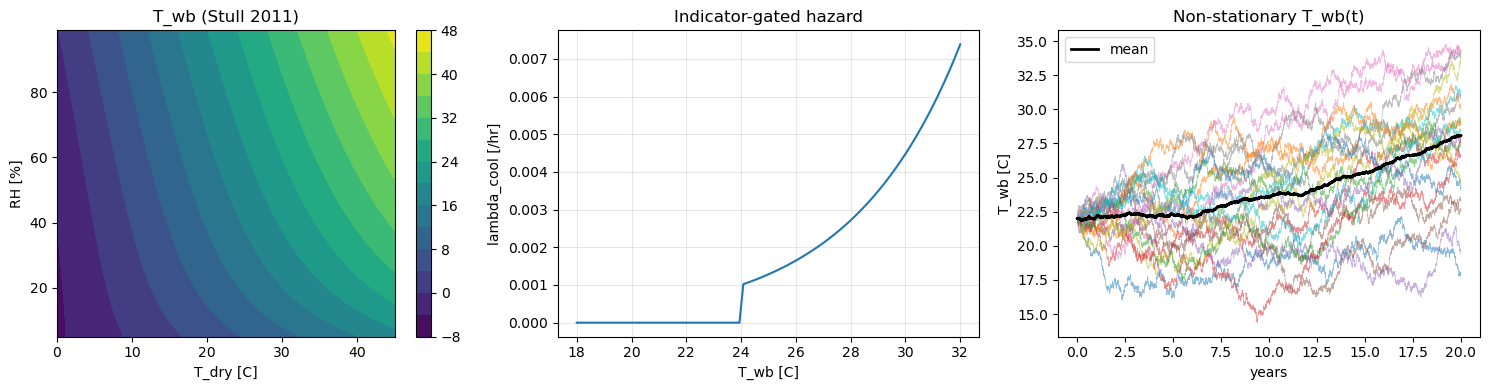

PUE @ (280K, 308K): 1.261818181818182


In [2]:
T = np.linspace(0, 45, 80); RH = np.linspace(5, 99, 80); TT, RR = np.meshgrid(T, RH)
Tw = wetbulb_stull(TT, RR)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
c1 = ax1.contourf(TT, RR, Tw, levels=15, cmap='viridis'); ax1.set_xlabel('T_dry [C]'); ax1.set_ylabel('RH [%]'); ax1.set_title('T_wb (Stull 2011)'); plt.colorbar(c1, ax=ax1)
Twg = np.linspace(18, 32, 100); ax2.plot(Twg, lambda_cool(Twg)); ax2.set_xlabel('T_wb [C]'); ax2.set_ylabel('lambda_cool [/hr]'); ax2.set_title('Indicator-gated hazard'); ax2.grid(alpha=0.3)
rng = np.random.default_rng(7); t, X = simulate_Twb(T_years=20.0, n_paths=50, rng=rng)
for i in range(20): ax3.plot(t, X[i], lw=0.5, alpha=0.5)
ax3.plot(t, X.mean(axis=0), 'k-', lw=2, label='mean'); ax3.set_xlabel('years'); ax3.set_ylabel('T_wb [C]'); ax3.set_title('Non-stationary T_wb(t)'); ax3.legend()
fig.tight_layout(); fig.savefig('fig_07_cooling.png', dpi=150); plt.show()
print('PUE @ (280K, 308K):', pue(280.0, 308.0).pue)